# Machine Learning — Predicting Mobility from COVID-19 Policy Indicators

The goal of this stage is to extend the policy–mobility analysis by using machine learning to evaluate whether mobility responses can be predicted from government policy indicators. Instead of only testing statistical associations, this section examines how well mobility outcomes can be predicted on unseen time periods, and which policy measures contribute most to the prediction.

The analysis uses:

- Policy indicators **C1–C8**
- **E1 income support**
- **Stringency Index**

The primary prediction target is:

**Workplace mobility (`workplaces`)**

Workplace mobility is chosen because it showed the most consistent and policy-sensitive response in the EDA and hypothesis testing results.

# Machine Learning Methods Applied

**Supervised Learning — Regression (Level Prediction)**

Predict workplace mobility from policy indicators.

Input features: C1–C8 policy indicators, E1 income support, Stringency Index

Models used:

- Linear Regression — baseline interpretable model  
- Lasso Regression — feature selection to identify influential policies  
- Random Forest Regressor — non-linear benchmark model  

Evaluation metrics:

- R² (explained variance)  
- RMSE (prediction error)  
- Performance on a future test period


**Supervised Learning — Classification**

Predict whether a **large workplace mobility drop** occurs.

Label definition:

- 1 → mobility below median  
- 0 → otherwise

Models used:

- Logistic Regression 
- Random Forest Classifier

**Unsupervised Learning — Policy–Response Patterns**

Methods:

- PCA— reduces policy indicators into main policy dimensions  
- K-Means Clustering — groups countries by policy intensity and mobility response

### **Library Import & Data Loading**

In this step, I import the libraries required for the machine learning analysis and load the merged COVID-19 policy and mobility dataset. The libraries include:

- pandas and numpy for data handling  
- scikit-learn for regression models, preprocessing, and evaluation  
- matplotlib and seaborn for visualization

The dataset used here is the same merged panel dataset from the EDA and hypothesis testing stages. After loading the dataset, I inspect its shape and first few rows to verify that the features, date field, and mobility variables are correctly imported before moving on to model training.


In [27]:
# --- Libraries ---

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### Dataset Loading & Feature Definition

In this step, I load the merged COVID-19 mobility–policy dataset and define the workplace mobility variable as the prediction target, while C1–C8 policy indicators, E1 income support, and the stringency index are used as input features for the machine learning models.

In [28]:
# --- Load dataset ---

df = pd.read_csv("covid_merged_final.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (3872, 21)


,countrycode,country,date,retail,grocery,parks,transit,workplaces,residential,stringencyindex,c1_school_closing,c2_workplace_closing,c3_cancel_public_events,c4_restrictions_on_gatherings,c5_close_public_transport,c6_stay_at_home_requirements,c7_restrictions_on_internal_movement,c8_international_travel_controls,e1_income_support,confirmedcases,confirmeddeaths
0,BR,Brazil,2020-02-15,5.0,4.0,-5.0,8.0,6.0,0.0,11.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,BR,Brazil,2020-02-16,2.0,3.0,-13.0,3.0,0.0,1.0,11.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,BR,Brazil,2020-02-17,-2.0,0.0,-12.0,9.0,19.0,-1.0,11.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,BR,Brazil,2020-02-18,-3.0,-1.0,-11.0,9.0,15.0,-1.0,11.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,BR,Brazil,2020-02-19,-1.0,-2.0,-5.0,8.0,14.0,-1.0,11.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [29]:
# --- Define features (X) and target (y) ---

target_col = "workplaces"   # prediction target

feature_cols = [
    c for c in df.columns
    if c.startswith(("c1_", "c2_", "c3_", "c4_", "c5_", "c6_", "c7_", "c8_", "e1_", "stringency"))
]

X = df[feature_cols].copy()
y = df[target_col].copy()

# drop missing values to avoid training on partial rows
valid = pd.concat([X, y], axis=1).dropna()

X = valid[feature_cols]
y = valid[target_col]

print("Final modeling shape:", X.shape)

Final modeling shape: (3872, 10)


### Train–Test Split (Time-Aware)

I split the data into a training period and a later test period to avoid mixing past and future observations. (Avoid data leakage)

In [30]:
# ---- Time-Aware Train–Test Split ----

# bring back the date column for the filtered rows
df_valid = df.loc[valid.index].copy()

# ensure date is datetime
df_valid["date"] = pd.to_datetime(df_valid["date"])

# sort by time to avoid leakage
df_sorted = df_valid.sort_values("date")

# reorder X and y using the sorted dataframe
X_sorted = df_sorted[feature_cols]
y_sorted = df_sorted[target_col]

# 80% train — 20% test (future period kept as unseen data)
split_point = int(len(df_sorted) * 0.8)

X_train = X_sorted.iloc[:split_point]
X_test  = X_sorted.iloc[split_point:]

y_train = y_sorted.iloc[:split_point]
y_test  = y_sorted.iloc[split_point:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ---- Standardize Features (fit on train only) ----
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)


Train size: (3097, 10)
Test size: (775, 10)
Scaled shapes: (3097, 10) (775, 10)


### Supervised Learning — Regression Models

In this step, I train three regression models (Linear Regression, Lasso Regression, and Random Forest Regressor) on the scaled training data and evaluate their performance on the unseen test period.

In [31]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
results = []

# ---------- Linear Regression ----------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

results.append({
    "Model": "Linear Regression",
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "R2": r2_score(y_test, y_pred_lr)
})


# ---------- Lasso Regression ----------
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

results.append({
    "Model": "Lasso Regression",
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    "MAE": mean_absolute_error(y_test, y_pred_lasso),
    "R2": r2_score(y_test, y_pred_lasso)
})


# ---------- Random Forest Regressor ----------
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

results.append({
    "Model": "Random Forest Regressor",
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "R2": r2_score(y_test, y_pred_rf)
})


# ---------- Comparison Table ----------
results_df = pd.DataFrame(results)
results_df


,Model,RMSE,MAE,R2
0,Linear Regression,16.224722,12.163996,0.240354
1,Lasso Regression,16.224693,12.163013,0.240357
2,Random Forest Regressor,17.855254,12.781523,0.079999


# Visualization

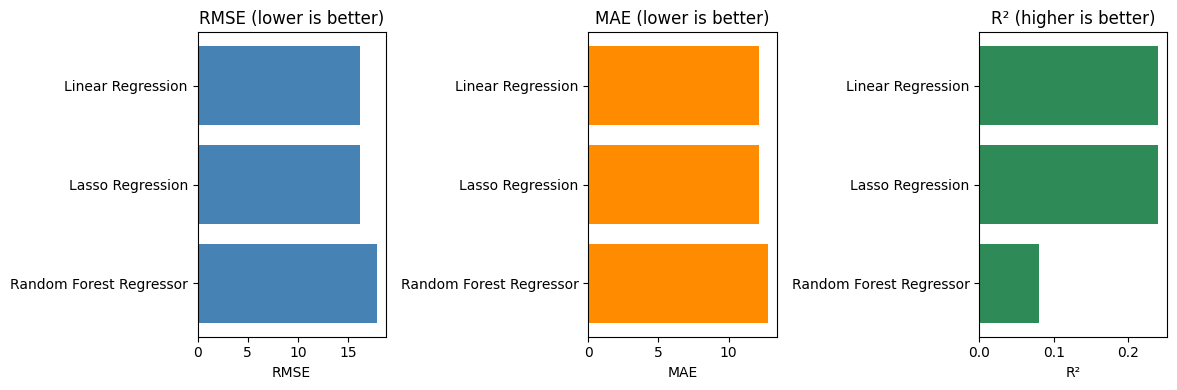

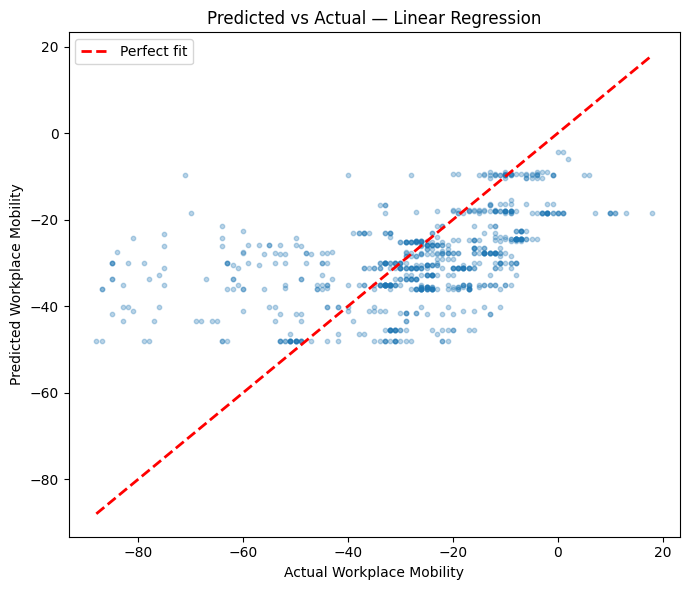

In [32]:
import matplotlib.pyplot as plt

# ---- 1) Model Comparison Bar Chart ----
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

models_list = results_df["Model"].tolist()

axes[0].barh(models_list, results_df["RMSE"], color="steelblue")
axes[0].set_xlabel("RMSE")
axes[0].set_title("RMSE (lower is better)")
axes[0].invert_yaxis()

axes[1].barh(models_list, results_df["MAE"], color="darkorange")
axes[1].set_xlabel("MAE")
axes[1].set_title("MAE (lower is better)")
axes[1].invert_yaxis()

axes[2].barh(models_list, results_df["R2"], color="seagreen")
axes[2].set_xlabel("R²")
axes[2].set_title("R² (higher is better)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# ---- 2) Predicted vs Actual Scatter (Best Model = Linear) ----
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_best = lr.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect fit")
plt.xlabel("Actual Workplace Mobility")
plt.ylabel("Predicted Workplace Mobility")
plt.title("Predicted vs Actual — Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

Compared 3 regression models to predict workplace mobility. Linear regression and Lasso performed similarly with R^2 around 0.24, while RF performed worse with 0.08. So relationship between policies and mobility is mostly linear is mostly linear.

Scatter plot shows how well the model predicts match actual values. Most predictions follow general trend, but there is still some spread and extreme values.

## Feature Importance — Lasso Regression

Lasso regression assigns coefficients to each policy indicator, showing how strongly each feature contributes to predicting workplace mobility.

- **Positive coefficient:** Higher policy value is associated with higher (less negative) workplace mobility
- **Negative coefficient:** Higher policy value is associated with lower (more negative) workplace mobility
- **Larger absolute value:** Stronger influence on prediction

This helps identify which COVID-19 policies had the most predictive power for workplace mobility changes.

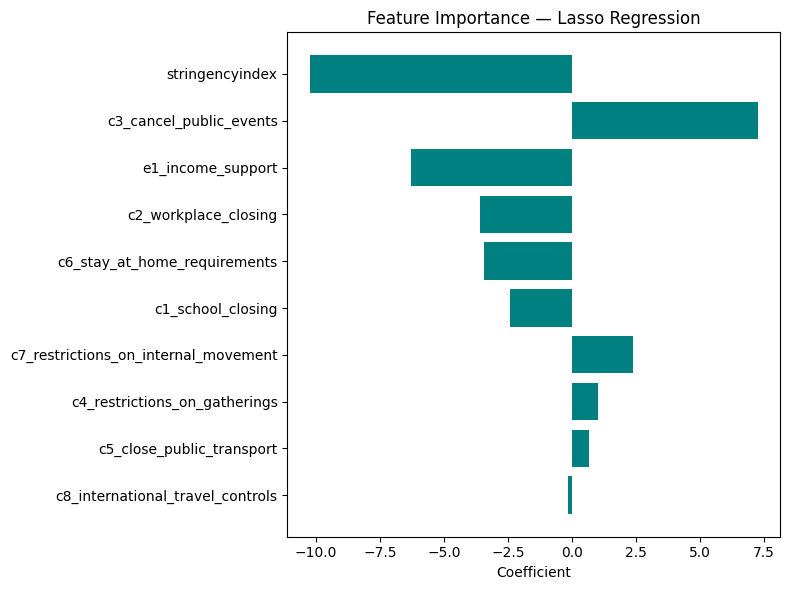

In [33]:
# ----  Feature Importance (Lasso Coefficients) ----
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lasso.coef_
}).sort_values("coefficient", key=abs, ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(coef_df["feature"], coef_df["coefficient"], color="teal")
plt.xlabel("Coefficient")
plt.title("Feature Importance — Lasso Regression")
plt.tight_layout()
plt.show()

**Key Findings:**

The stringency index and income support policies have the strongest predictive power for workplace mobility reductions. 
Cancelling public events shows a positive coefficient, which is unexpected.

# Supervised Learning — Classification (Mobility Drop Detection)

- Add classification task — mobility drop  
- Train logistic + random forest  
- Evaluate accuracy + F1 score  
- Plot confusion matrix (test)  
- Compare results with regression

In [34]:
# ---- Supervised Learning — Classification (Mobility Drop Detection) ----

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

# ----- Create Binary Label -----
# 1 → large drop (below median)
# 0 → otherwise

threshold = y_train.median()

y_train_cls = (y_train < threshold).astype(int)
y_test_cls  = (y_test  < threshold).astype(int)

print("Label threshold (median mobility):", round(threshold, 2))


# ----- Train Logistic Regression -----
log_clf = LogisticRegression(max_iter=200)
log_clf.fit(X_train_scaled, y_train_cls)

y_pred_log = log_clf.predict(X_test_scaled)


# ----- Train Random Forest -----
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf_clf.fit(X_train_scaled, y_train_cls)

y_pred_rf = rf_clf.predict(X_test_scaled)


# ----- Evaluation Function -----
def cls_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred)
    }


results_cls = [
    {"Model": "Logistic Regression", **cls_metrics(y_test_cls, y_pred_log)},
    {"Model": "Random Forest Classifier", **cls_metrics(y_test_cls, y_pred_rf)}
]

results_cls_df = pd.DataFrame(results_cls)
results_cls_df
 

Label threshold (median mobility): -21.0


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.723871,0.744376,0.803532,0.772824
1,Random Forest Classifier,0.709677,0.740506,0.774834,0.757282


Combines precision + recall into one score

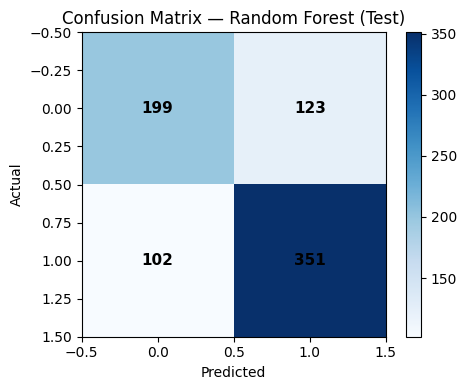

In [35]:
cm = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")   # <-- nicer color scale
plt.title("Confusion Matrix — Random Forest (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# add value labels
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 fontsize=11, fontweight="bold")

plt.colorbar()
plt.tight_layout()
plt.show()

The classifier can predict large mobility drops fairly well, showing that policies do lead to real changes in behavior.

## Unsupervised Learning — Policy–Mobility Response Clusters

Unsupervised learning is used to explore whether countries form natural groups
based on (a) COVID-19 policy strictness and (b) workplace mobility response.

We apply K-Means clustering to identify policy–response patterns without using
any target variable or supervision.

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------- Features for clustering --------
cluster_features = [
    "stringencyindex",
    "c1_school_closing",
    "c2_workplace_closing",
    "c3_cancel_public_events",
    "c4_restrictions_on_gatherings",
    "c5_close_public_transport",
    "c6_stay_at_home_requirements",
    "c7_restrictions_on_internal_movement",
    "c8_international_travel_controls",
    "workplaces"
]

# use the dataframe we already used in ML
df_cluster = df[cluster_features].dropna()

# scale features so all contribute equally
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster)

# -------- K-Means (3 policy–response groups) --------
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X_cluster)

# cluster center preview
df_cluster.groupby("cluster")["workplaces"].mean()


cluster
0   -35.313180
1   -18.865003
2    -9.338931
Name: workplaces, dtype: float64

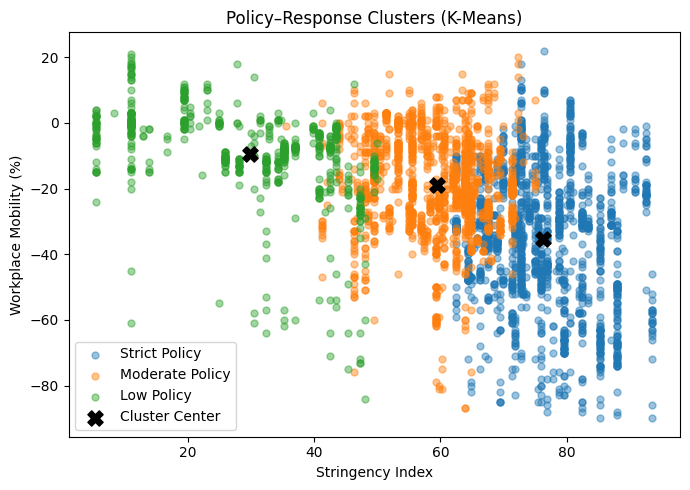

In [46]:
# ---- Visualize Policy–Response Clusters ----
import matplotlib.pyplot as plt
import numpy as np

# --- Cluster name mapping for visualization ---
cluster_names = {
    0: "Strict Policy",
    1: "Moderate Policy",
    2: "Low Policy"
}

plt.figure(figsize=(7,5))

# scatter points with named clusters
for c in sorted(df_cluster["cluster"].unique()):
    subset = df_cluster[df_cluster["cluster"] == c]
    plt.scatter(
        subset["stringencyindex"],
        subset["workplaces"],
        alpha=0.45,
        s=25,
        label=cluster_names.get(c, f"Cluster {c}")
    )

# plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_x = centers[:, cluster_features.index("stringencyindex")]
centers_y = centers[:, cluster_features.index("workplaces")]

plt.scatter(
    centers_x, centers_y,
    color="black",
    s=120,
    marker="X",
    label="Cluster Center"
)

plt.xlabel("Stringency Index")
plt.ylabel("Workplace Mobility (%)")
plt.title("Policy–Response Clusters (K-Means)")
plt.legend()
plt.tight_layout()
plt.show()


Surprisingly, Cluster 2 (green) saw the largest drop in mobility despite having lower stringency scores than Cluster 0. This suggests that fear or cultural norms drove high compliance, even without strict government mandates.

# Machine Learning - Conclusions

1- The ML results show that COVID-19 policies are related to workplace mobility, but they do not fully predict it.

2- Regression models explain part of the changes, and the classifier can detect big mobility drops with above average accuracy.

3- The clusters also show that some countries reacted strongly to strict policies, while others showed weaker responses.

***Overall, policies matter - but human behavior is more complex than what models can fully capture.***